## Environment Setup, Data Cleansing, and Feature Engineering

In this initial section, we prepare the project environment and execute the *Data Cleansing* and *Feature Engineering* phases.

The used functions are kept into separate Python scripts (`data_cleansing.py`, `feature_engineering.py`, etc.). In this cell, we import these custom modules and apply the data pipelines to the raw flight dataset.

**Execution steps:**

* *Environment Initialization:* Set up system paths to access custom modules, suppress non-critical warnings for cleaner output.
* *Data Loading:* Load the dataset of 3m rows
* *Data Cleansing Pipeline:* Execute `run_data_cleansing_pipeline()` to handle missing values, resolve formatting inconsistencies, remove duplicate records and drop post-event variables to prevent data leakage.
* *Feature Engineering Pipeline:* Execute `run_feature_engineering_pipeline()` to generate new predictive attributes
* *Data Checkpointing:* Save the intermediate datasets (`cleansed_flights_data.csv` and `engineered_flights_data.csv`) to disk


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.append(os.path.abspath('Python Version'))

# Now Python will successfully find your scripts!
from data_cleansing import *
from feature_engineering import *
from dimensionality_reduction import *
from EDA import *
from hypothesis_testing import *

# Load the dataset
file_path = '../Project_Datasets/flights_sample_3m.csv'
df = pd.read_csv(file_path)

# Print the initial shape to show the RAW data size
print("Initial dataset shape before cleansing (rows, columns):", df.shape)

# Run data cleansing
df = run_data_cleansing_pipeline(df)

output_filename = '../Project_Datasets/cleansed_flights_data.csv'
df.to_csv(output_filename, index=False)

# Print the initial shape to show the RAW data size
print("\nDataset shape after cleansing (rows, columns):", df.shape)

#Run feature engineering
df = run_feature_engineering_pipeline(df)

output_filename = '../Project_Datasets/engineered_flights_data.csv'
df.to_csv(output_filename, index=False)

Initial dataset shape before cleansing (rows, columns): (11364, 32)

Dataset shape after cleansing (rows, columns): (11058, 11)


## Descriptive Statistics 

This is the start of the Exploratory Data Analysis (EDA)

Here we conduct descriptive statistics (such as the mean, median, standard deviation, minimum, and maximum values) and export them to CSV files.

To keep the analysis organized, the variables are separated into two distinct groups:
* *Base Features:* The base metrics provided in the original dataset, including flight distance, scheduled duration, and the target variable, arrival delay.
* *Engineered Features:* The newly created metrics, such as scheduled speeds, origin/destination congestion

In [2]:
# Show the size of the data after cleansing
print("Cleaned Dataset Shape:", df.shape)

# 1. Check statistics for Base Features
print("\n--- Data Cleansing Results ---")
base_features = ['DISTANCE', 'CRS_ELAPSED_TIME', 'ARR_DELAY']
run_descriptive_statistics(df, base_features, "descriptive_statistics_base_features.csv")

# 2. Check statistics for Engineered Features
print("\n--- Feature Engineering Results ---")
new_masterpiece_features = [
    'SCHEDULED_SPEED',
    'ORIGIN_CONGESTION',
    'DESTINATION_CONGESTION',
    'ROUTE_BOTTLENECK_INTERACTION',
    'AIRLINE_HUB_DOMINANCE',
    'ROUTE_FREQUENCY',
]
run_descriptive_statistics(df, new_masterpiece_features, "descriptive_statistics_engineered_features.csv")

Cleaned Dataset Shape: (11058, 24)

--- Data Cleansing Results ---

--- DESCRIPTIVE STATISTICS & DATA OVERVIEW ---

Basic Summary Statistics:
       DISTANCE  CRS_ELAPSED_TIME  ARR_DELAY
count  11058.00          11058.00   11058.00
mean     808.14            142.22      12.79
std      585.21             71.21      45.58
min       31.00             28.00       0.00
25%      383.00             90.00       0.00
50%      651.00            125.00       0.00
75%     1044.75            173.00       6.00
max     5095.00            665.00    1185.00

Variance:
DISTANCE            342475.53
CRS_ELAPSED_TIME      5071.20
ARR_DELAY             2077.82
dtype: float64

Skewness:
DISTANCE             1.56
CRS_ELAPSED_TIME     1.49
ARR_DELAY           11.43
dtype: float64

Kurtosis:
DISTANCE              3.32
CRS_ELAPSED_TIME      3.02
ARR_DELAY           205.84
dtype: float64

--- Feature Engineering Results ---

--- DESCRIPTIVE STATISTICS & DATA OVERVIEW ---

Basic Summary Statistics:
       SCHEDUL

## Exploratory Data Analysis (EDA)
### Theme 1: The True Shape of Flight Delays

Here we start performing EDA to examine the statistical distribution of our variables, focusing specifically on their centrality, dispersion, and overall shape 

The first plot represents the *Distribution Shape: Frequency and Density of Arrival Delays*.

We employ a *Simple Random Sampling* strategy to reduce to computational cost. By selecting a smaller, representative subset of 10,000 records, we ensure that every flight has an equal probability of being chosen

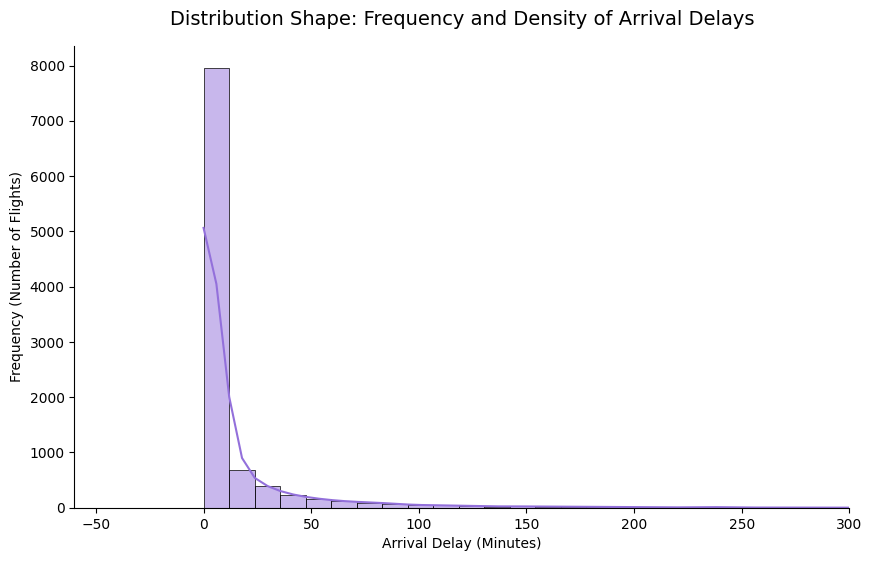

In [3]:
# Create a simple random sample of 10,000 records for faster, cleaner plotting 
df_sample = df.sample(n=10000, random_state=42)

# Generate the plot
plot_delay_distribution(df_sample)

### Theme 2: Temporal and Seasonal Delay Trends

In this step, we examine the Temporal Trends.

We first temporarily reconstruct the `MONTH` and `DEP_HOUR` dimensions from the `FL_DATE` and `CRS_DEP_TIME` columns. 

Next, we visualize the average arrival delays using line charts. We generate two temporal plots:
* *Average Delay by Month* To identify broad seasonal patterns, such as the impact of holidays, summer thunderstorms or winter holiday congestion.
* *Average Delay by Time of Day* To track daily operational patterns

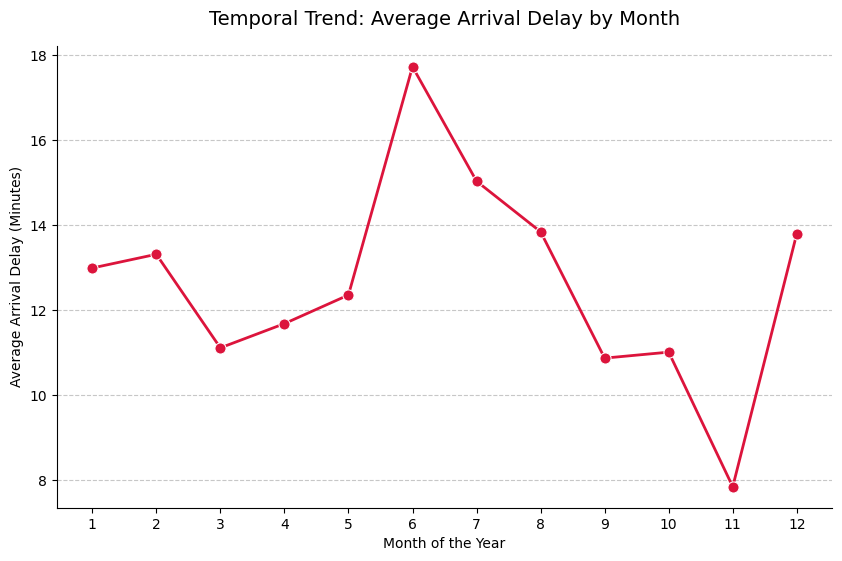

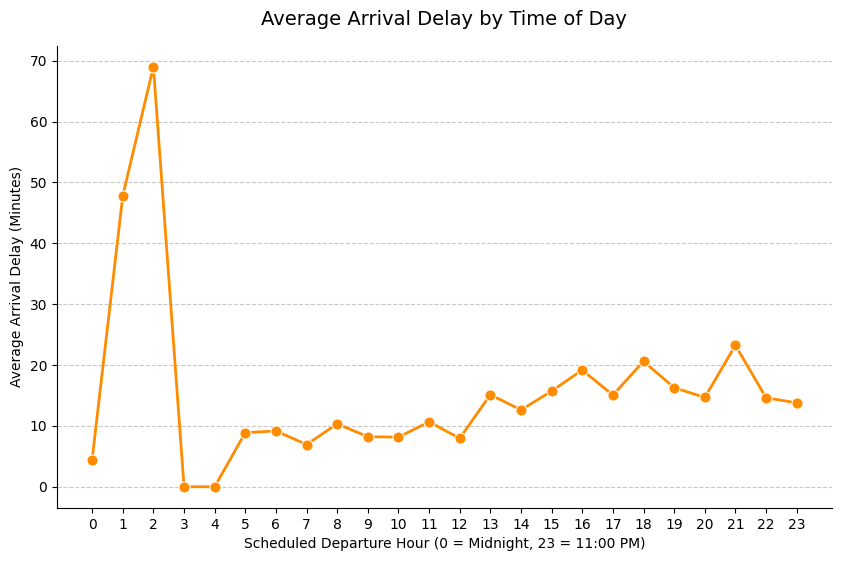

In [4]:
# Recreate DEP_HOUR temporarily
if 'MONTH' not in df.columns: 
    df['MONTH'] = df['FL_DATE'].astype(str).str[5:7].astype(int)
    
if 'DEP_HOUR' not in df.columns: 
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
    
# Call the Generalized Line Chart for MONTHS
plot_temporal_delay_trend(
    df=df,
    time_col='MONTH',
    title='Temporal Trend: Average Arrival Delay by Month',
    xlabel='Month of the Year',
    xticks_range=range(1, 13),
    line_color='crimson'
)

# Call the Generalized Line Chart for HOURS
plot_temporal_delay_trend(
    df=df,
    time_col='DEP_HOUR',
    title='Average Arrival Delay by Time of Day',
    xlabel='Scheduled Departure Hour (0 = Midnight, 23 = 11:00 PM)',
    xticks_range=range(0, 24),
    line_color='darkorange'
)

### Theme 3: The Distance Divide: Short-Haul vs. Long-Haul

In this phase we assess the correlation between the variablesinvestigating the constraints of the flights by comparing their distances, scheduled durations, and operational speeds.

First, we use a *Scatterplot* to illustrate the *Linear Correlation between Distance and Scheduled Flight Duration*. 

Next, we categorize the data by Flight Haul Type to see how operational efficiency changes depending on the route length. We visualize this using two chartS:
* *Distribution Shape: Scheduled Speed by Flight Haul Type (Violin Plot)*
* *Categorical Boxplots*: we use these to show percentile values, the median, the interquartile range, and the outliers for the main continuous features.

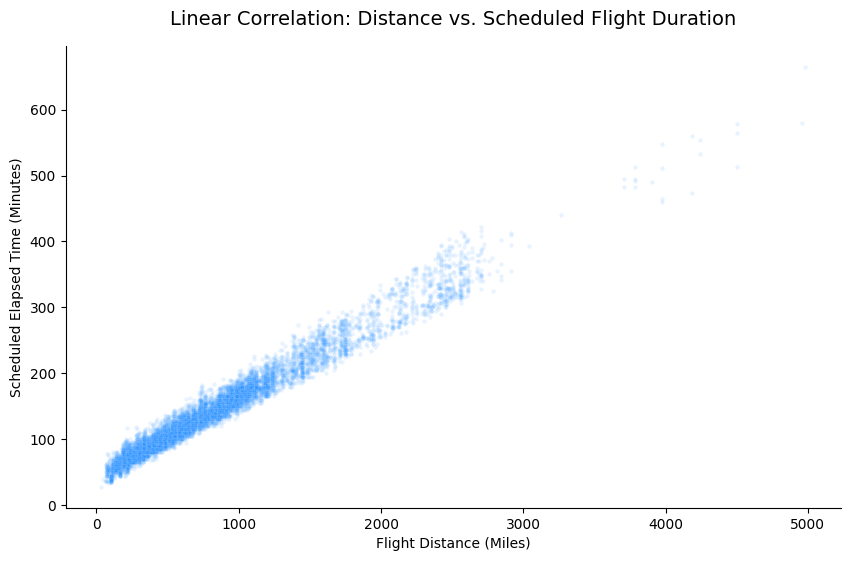

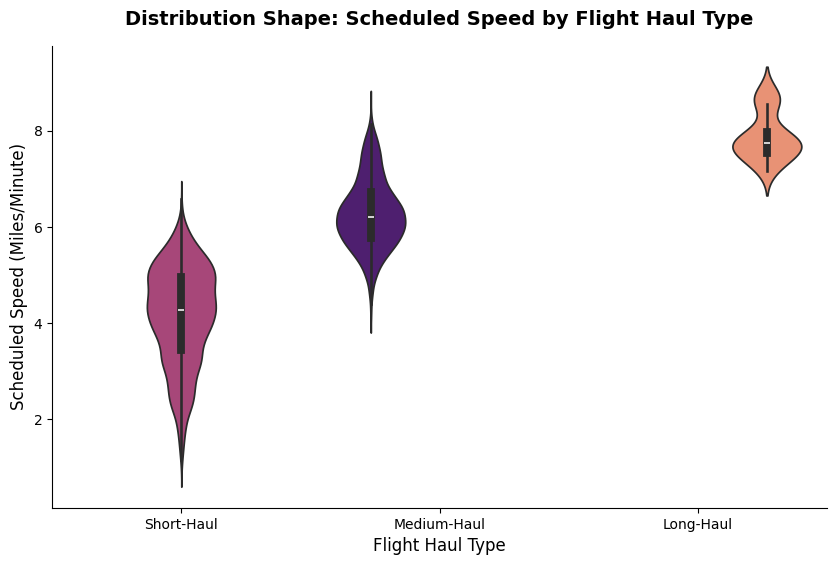

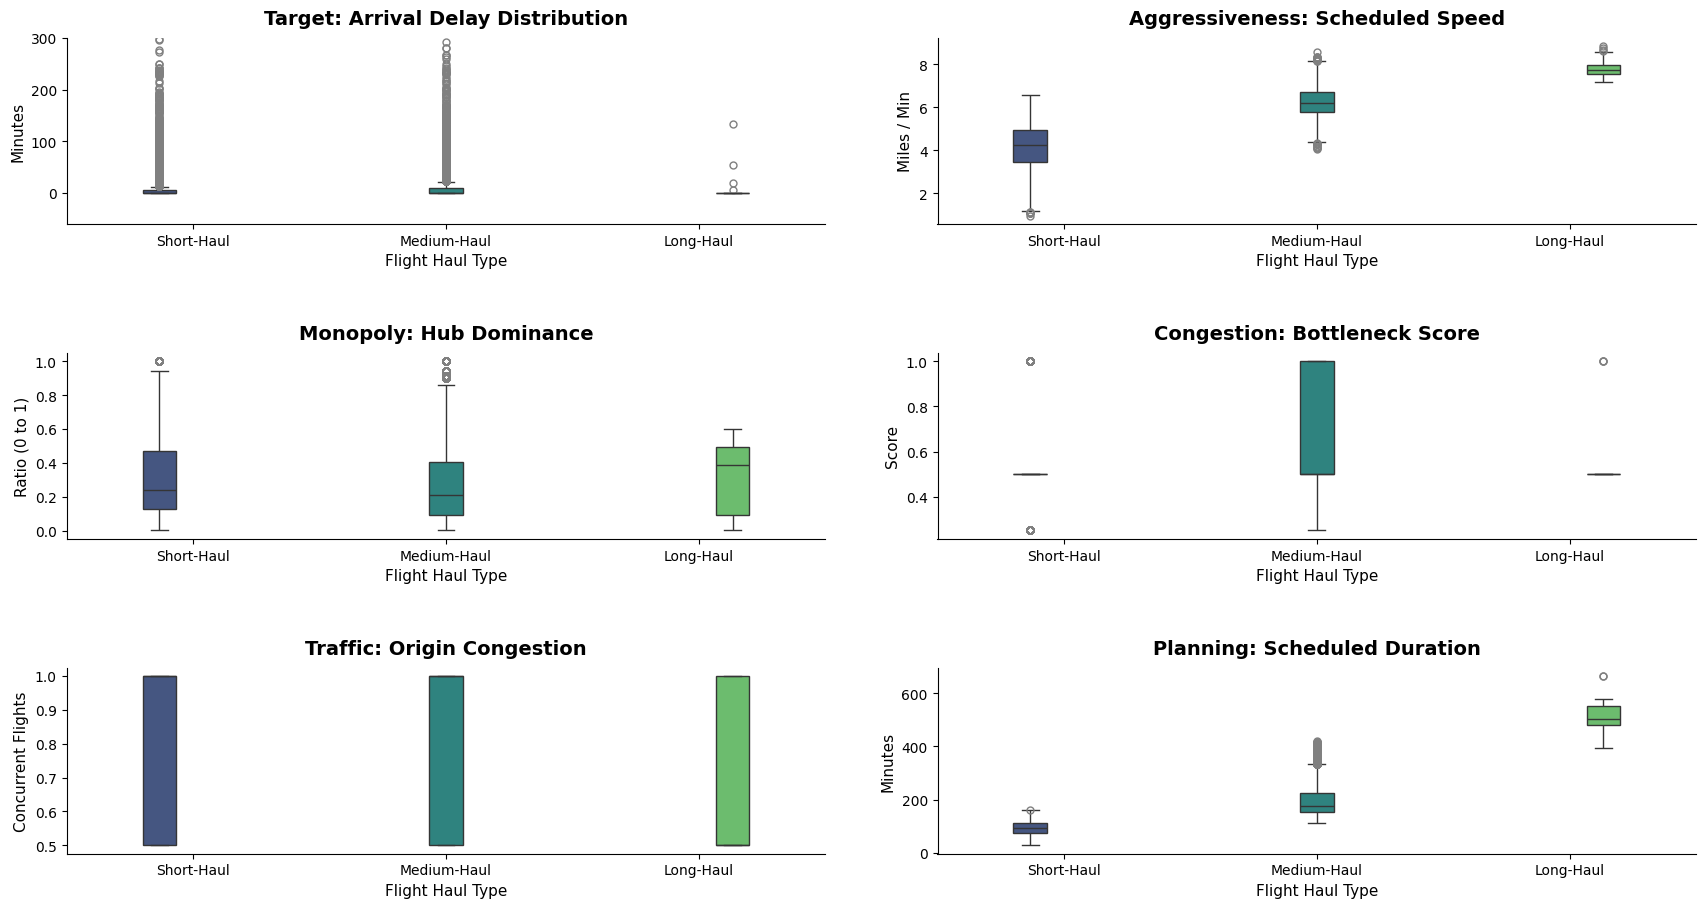

In [5]:
# Generate the scatter plot for Distance vs Duration
plot_distance_vs_duration(df_sample)

# Generate the violin plot and boxplots for Flight Haul Types [2, 3]
plot_speed_violin_distribution(df)
plot_categorical_boxplots(df)

### Theme 4: Operational Efficiency vs. Congestion

In this section we evaluate the operational performance of the airlines and the origin airports to determine if severe delays are strictly driven by heavy flight volume or if they are influenced by business strategies, such as hub dominance and congestion.

To analyze this, we generate the next plots:
* Executive Porifle by Origin Airport / Airline (Grid Charts, Bar Plot):* We explore the performance of each Airline and the Top 15 Origin Airports.
* *Average Hub Dominance vs Average Delay by Airline/Airport (Bubble Charts):* where the size of the bubble depicts the Flight Volume, adding a third domension of information
* **Scatterplots:** Finally, we use a grid of scatterplots to illustrate the linear correlation between our engineered Origin/Destination Congestion metrics and the final Arrival Delay.

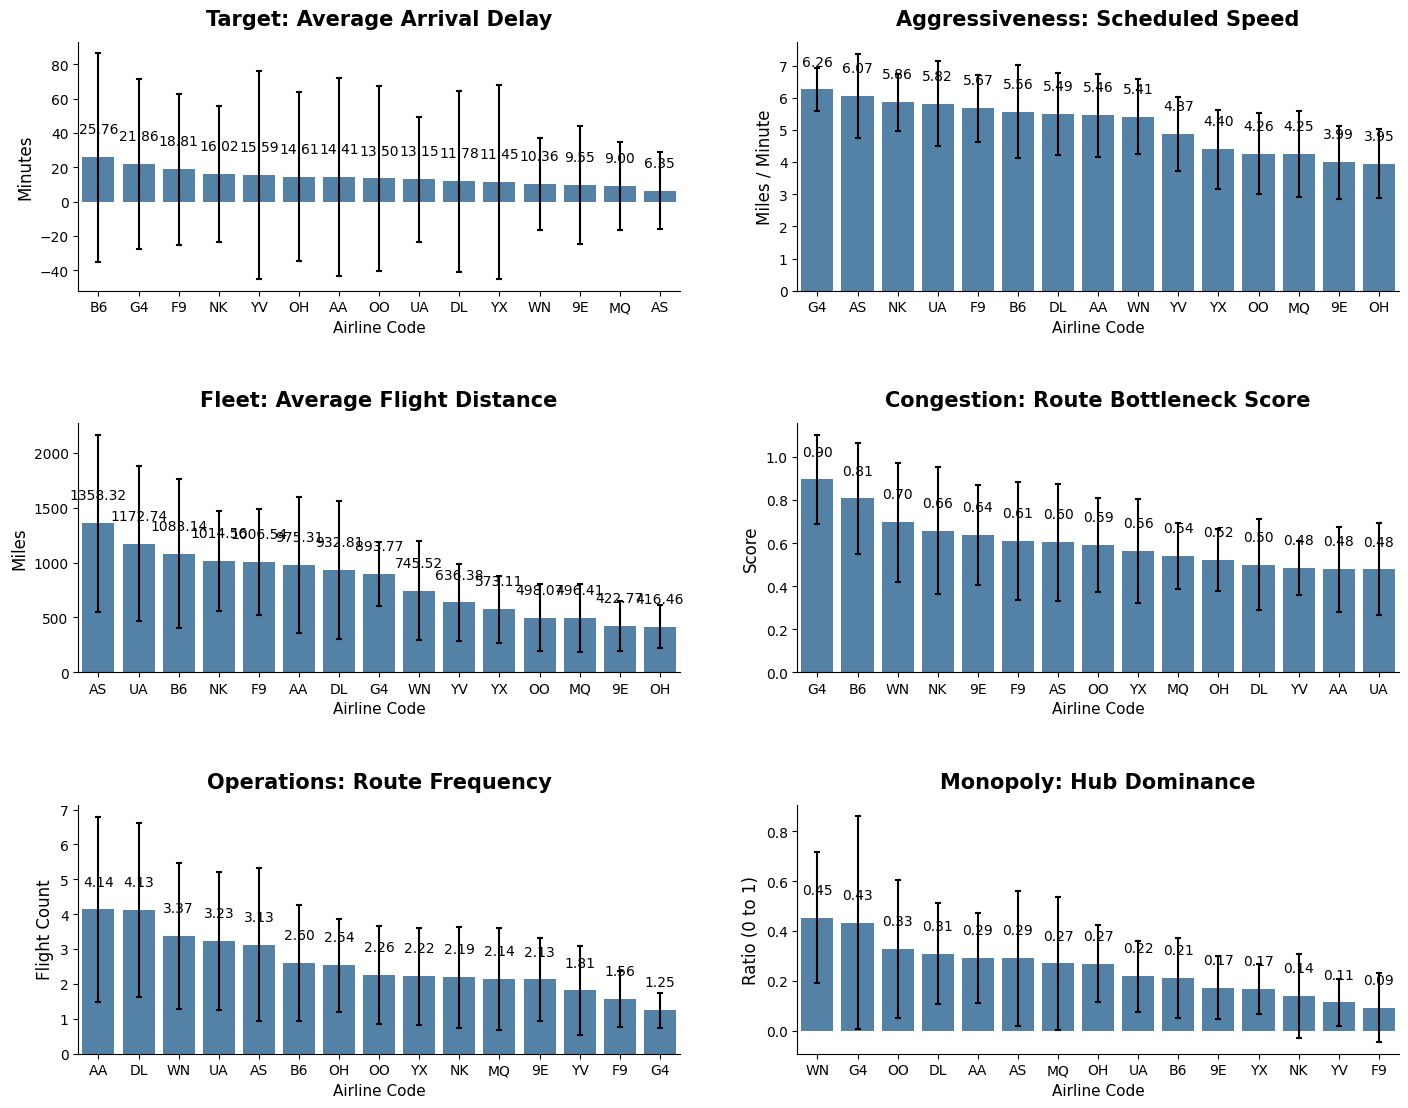

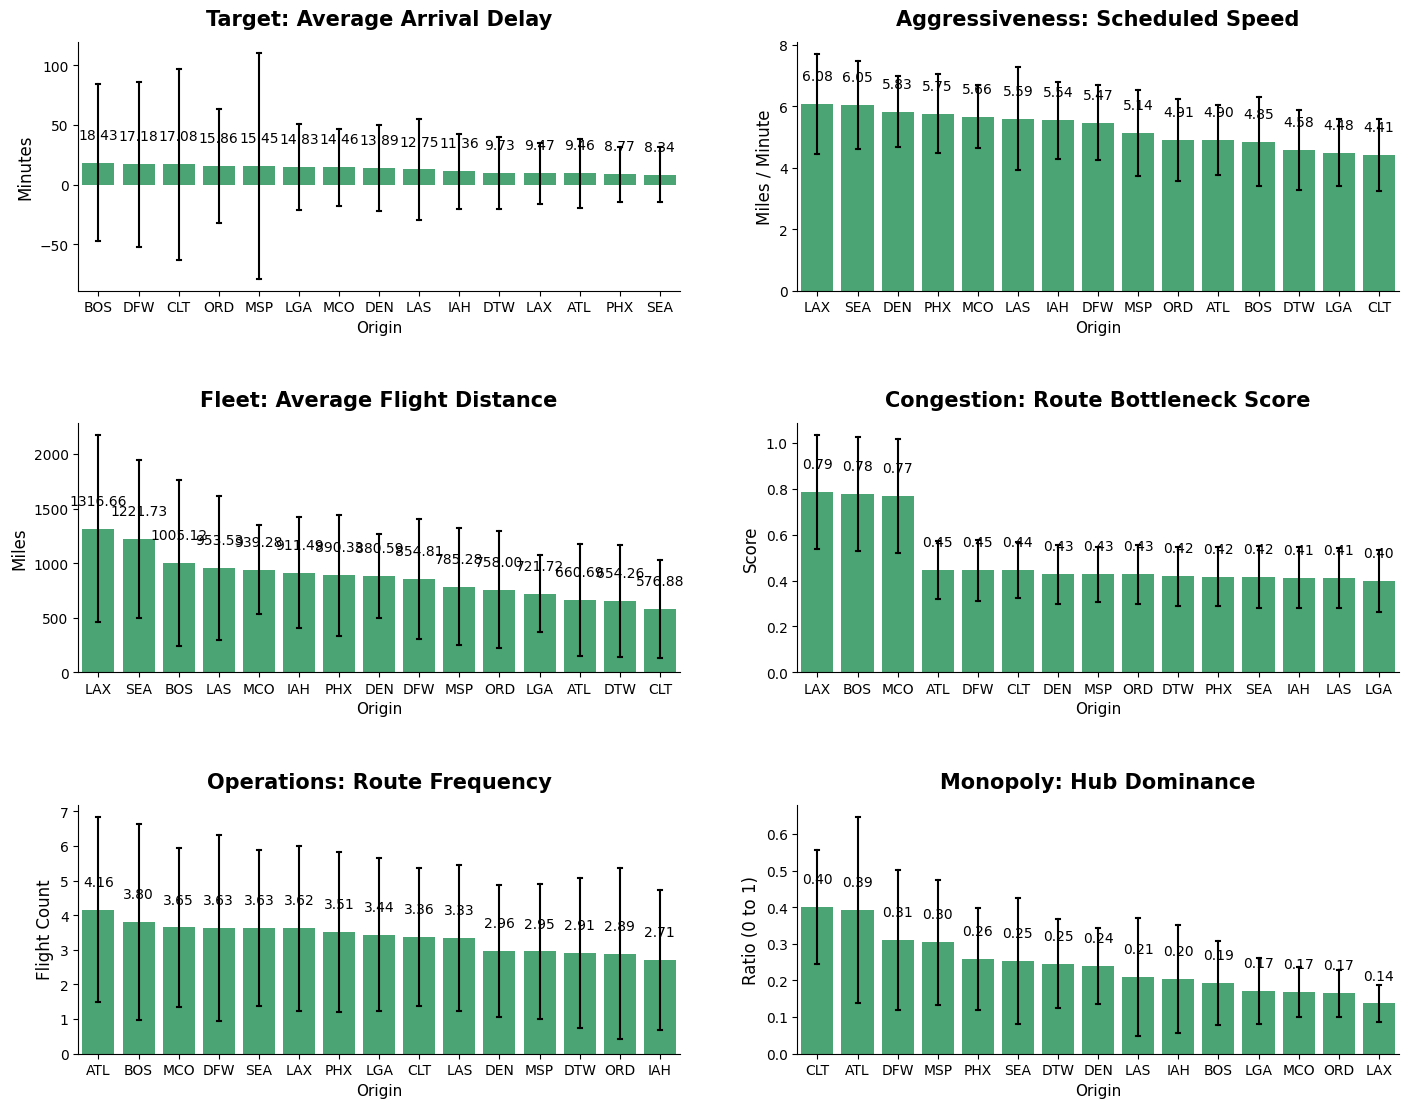

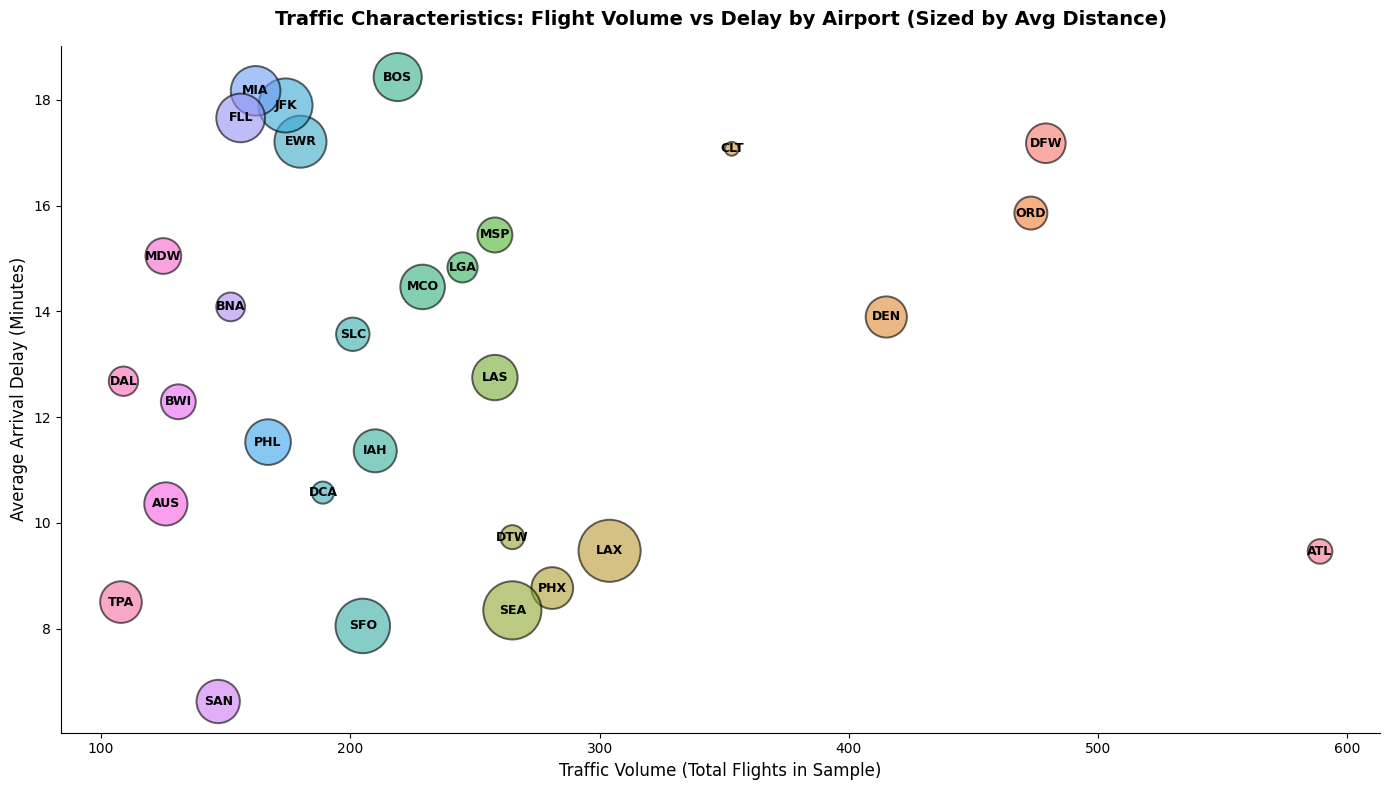

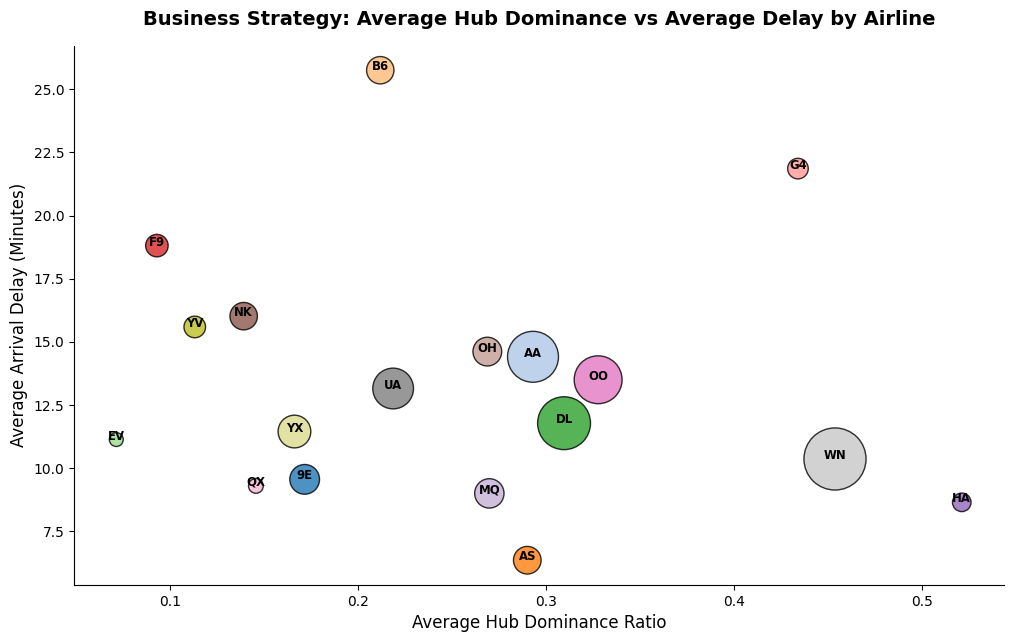

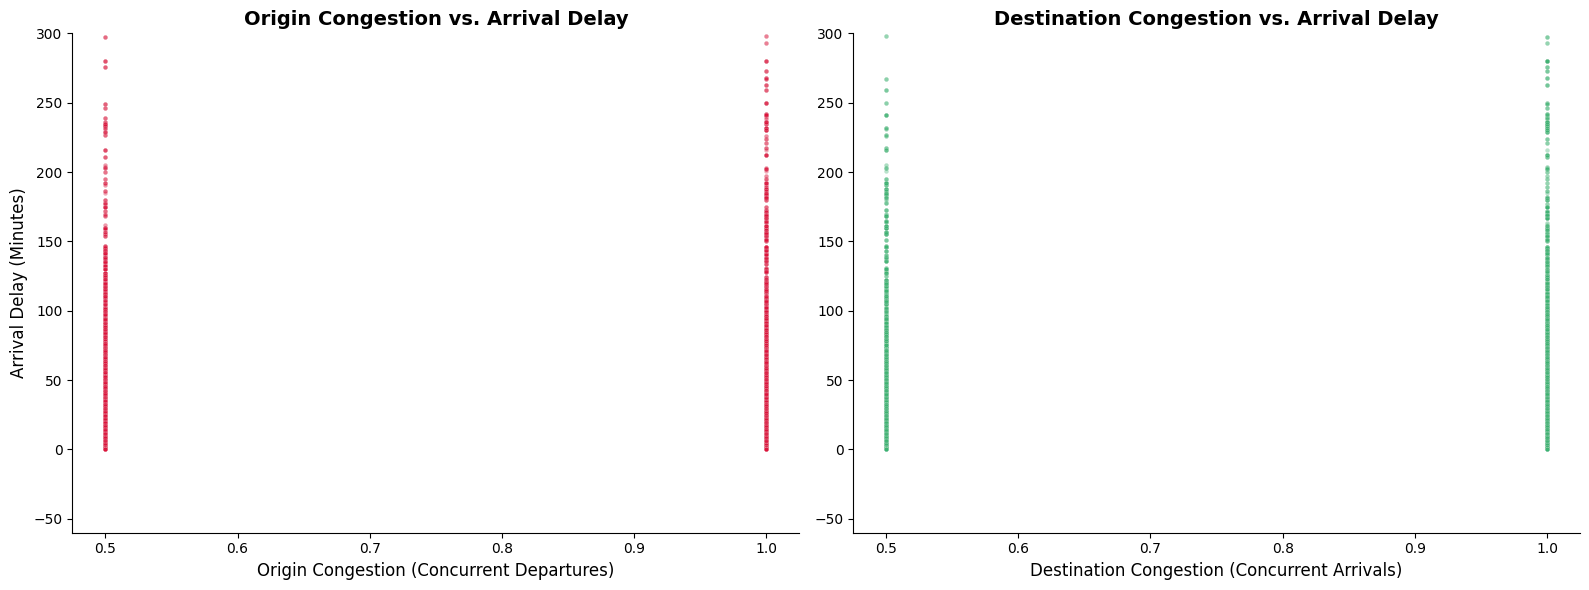

In [6]:
# Executive profiles for Airlines and Origins [2]
plot_executive_profile(df, categorical_col='AIRLINE_CODE', plot_color='steelblue') 
plot_executive_profile(df, categorical_col='ORIGIN', top_n=15, plot_color='mediumseagreen')

# Generate the Bubble Chart and Congestion Grid [3]
plot_executive_bubble_chart(df)
plot_dominance_bubble(df)
plot_congestion_vs_delay_grid(df)

## Outlier Detection and Removal

In this phase we handle outliers, which are data points that deviate significantly from the norm. If not removed, these extreme values can severely distort the algorithms and reduce predictive accuracy.

To accurately identify and remove the outliers, we use the *Isolation Forest* algorithm, an unsupervised machine learning algorithm that creates an ensemble of decision trees where each tree randomly selects features and splits values. 

In the following cell, we apply the Isolation Forest algorithm to the continuous physical features of our flights (`DISTANCE`, `CRS_ELAPSED_TIME`, and `SCHEDULED_SPEED`) with a defined contamination rate of 1%. 

In the end we save the new dataset to disk.

In [7]:
iso_features = ['DISTANCE', 'CRS_ELAPSED_TIME', 'SCHEDULED_SPEED']
df = remove_outliers_isolation_forest(df, iso_features, contamination=0.01)

output_filename = '../Project_Datasets/removed_outliers_data.csv'
df.to_csv(output_filename, index=False)


--- Removing Outliers using Isolation Forest ---
Original dataset size: 11058 rows
Training model on sample...
Dropped 110 anomalous rows.
New dataset size: 10948 rows


## Dimensionality Reduction

We use *Dimensionality Reduction*, which reduces the number of features by transforming the data into a lower-dimensional space but still keeping the most essential information.

Before applying the algorithms, the data must undergo *Feature Scaling*, since dimensionality reduction algorithms are highly sensitive to the scale of the data and if features are on different orders of magnitude, the algorithms cannot correctly compute the optimal components. 

We evaluate our data using both a linear and a non-linear method:
* *Principal Component Analysis (PCA):* A linear dimensionality reduction technique that finds principal components to explain the maximum variance in the data. It produces a new feature space where variables are independent and non-redundant. 
* *Uniform Manifold Approximation and Projection (UMAP):* A non-linear technique that constructs a fuzzy topological representation of the data, preserving local and global data structures.

In the following cell, we execute the dimensionality reduction pipeline (Scaling, PCA, and UMAP) and save the final scaled dataset to disk.

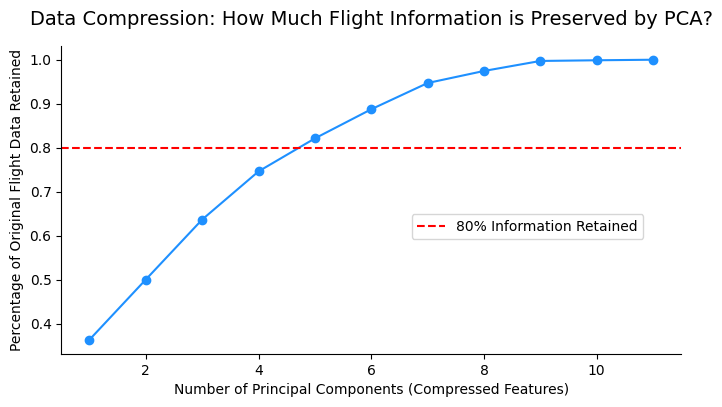

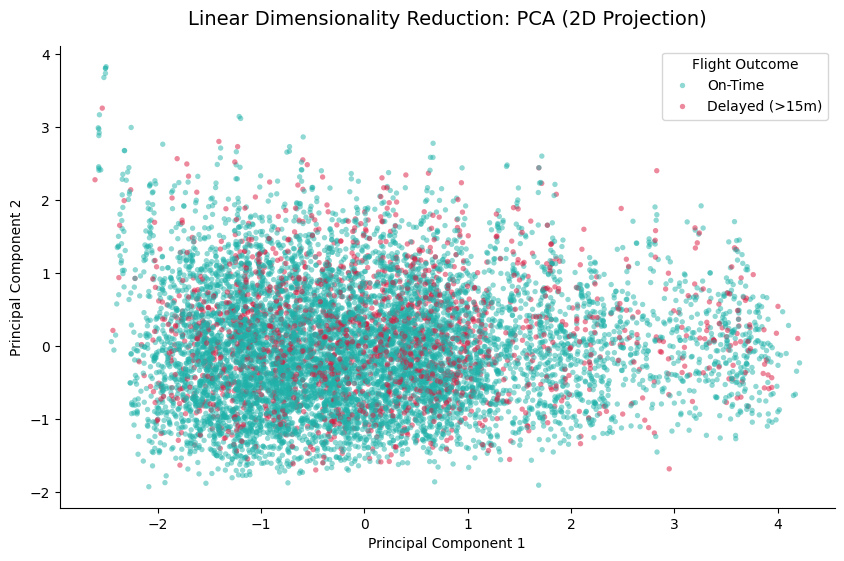

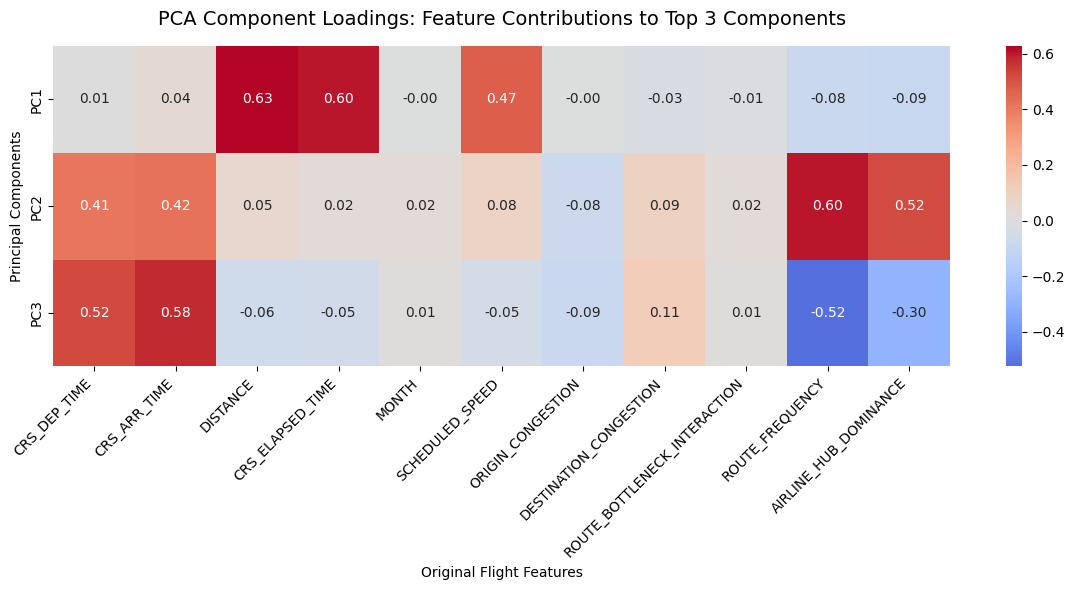

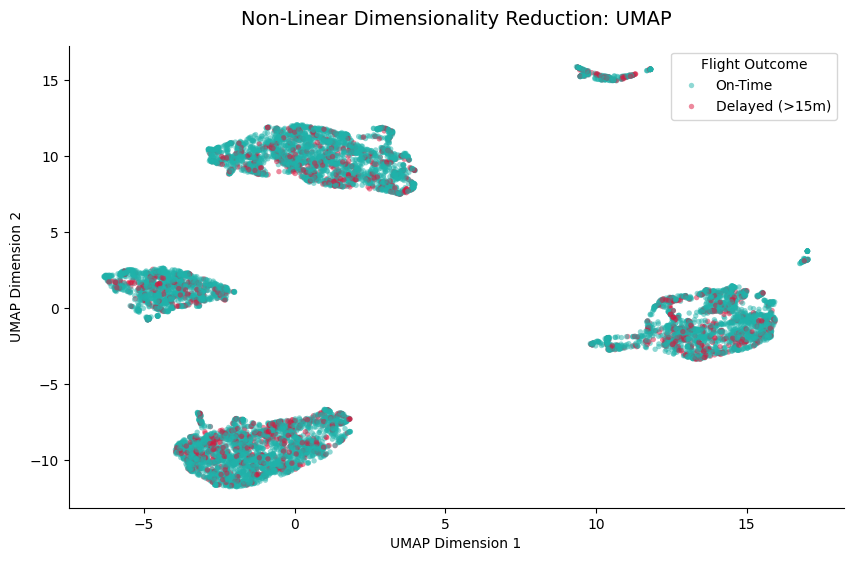

In [8]:
# Run the entire dimensionality reduction pipeline (Scaling, PCA, and UMAP)
execute_dimensionality_reduction(df)

output_filename = '../Project_Datasets/scaled_data.csv'
df.to_csv(output_filename, index=False)

In [9]:
# Recreate DEP_HOUR temporarily
if 'MONTH' not in df.columns: 
    df['MONTH'] = df['FL_DATE'].astype(str).str[5:7].astype(int)
    
if 'DEP_HOUR' not in df.columns: 
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
    
# Hypothesis 1: Departure Time Effect
print("\nTest 1: Does the scheduled Time of Day (Departure Hour) significantly affect delays?")
perform_kruskal_wallis(df, group_col='DEP_HOUR', target_col='ARR_DELAY');

# Hypothesis 2: Month Effect
print("\nTest 2: Does the Month of the year significantly affect arrival delays?")
perform_kruskal_wallis(df, group_col='MONTH', target_col='ARR_DELAY');


Test 1: Does the scheduled Time of Day (Departure Hour) significantly affect delays?
--- Kruskal-Wallis Test: DEP_HOUR vs ARR_DELAY ---
H-statistic: 276.32
P-value: 0.0000
Conclusion: Reject H0. 'DEP_HOUR' systematically impacts 'ARR_DELAY'.


Test 2: Does the Month of the year significantly affect arrival delays?
--- Kruskal-Wallis Test: MONTH vs ARR_DELAY ---
H-statistic: 69.40
P-value: 0.0000
Conclusion: Reject H0. 'MONTH' systematically impacts 'ARR_DELAY'.

